<a href="https://colab.research.google.com/github/Ali-Hider/Drone-Human-Detection-System/blob/main/Drone_Human_Detection_%26_Counting_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Overview

**Drone Human Detection & Counting System**
**Candidate:** MD Ali Hider
**Objective:** Build a computer vision pipeline to detect and count humans and cars in aerial drone imagery using the VisDrone dataset.
**Tools Used:**
YOLOv8 for Object Detection
OpenCV for Image Processing
Pandas for Data Analysis
KaggleHub for Dataset Management

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import kagglehub
from google.colab.patches import cv2_imshow

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [ ]:
path = kagglehub.dataset_download("banuprasadb/visdrone-dataset")
print("Path to dataset files:", path)

100%|██████████| 2.10G/2.10G [00:17<00:00, 132MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1


##Task 01: Dataset Understanding & Preprocessing

In this section, I analyze the structure of the VisDrone dataset, visualize the raw annotations, and define the preprocessing steps required for the model.

###1.1 Dataset Structure Analysis
The VisDrone dataset is organized into training, validation, and testing sets. Each set contains:
Images folder: High-resolution .jpg files.

Labels folder: Corresponding .txt files where each line contains: [class_id, x_center, y_center, width, height].

Key Classes for this task:

Class 0: Pedestrian

Class 1: People

Class 3: Car

To accurately count total humans, my system will aggregate detections from both the pedestrian (Class 0) and people (Class 1) categories, as both represent human targets from an aerial perspective

In [ ]:
base_path = os.path.join(path, 'VisDrone_Dataset')


train_img_path = os.path.join(base_path, 'VisDrone2019-DET-train/images')
train_lbl_path = os.path.join(base_path, 'VisDrone2019-DET-train/labels')


if os.path.exists(train_img_path):
    num_images = len(os.listdir(train_img_path))
    print(f"✅ SUCCESS! Path found.")
    print(f"Total images in training set: {num_images}")
else:
    print("❌ Path still incorrect. Let's see the contents of the nested folder:")
    print(os.listdir(base_path))

✅ SUCCESS! Path found.
Total images in training set: 6471


In [ ]:
print("Sample images:", os.listdir(train_img_path)[:5])

Sample images: ['0000342_00197_d_0000243.jpg', '9999955_00000_d_0000005.jpg', '9999951_00000_d_0000050.jpg', '9999951_00000_d_0000056.jpg', '0000042_01000_d_0000074.jpg']


###1.2 Sample Visualizations

To ensure the labels match the images, I have implemented a visualization script to draw bounding boxes on raw images.

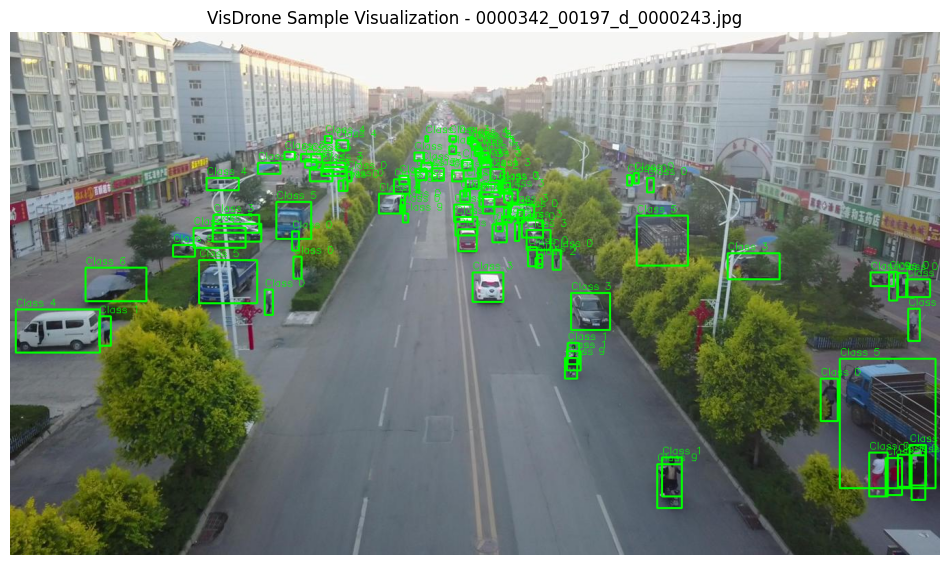

In [ ]:
# Select a sample image and its label
# We use the corrected paths from the previous step
img_name = os.listdir(train_img_path)[0]
img_path = os.path.join(train_img_path, img_name)
label_path = os.path.join(train_lbl_path, img_name.replace('.jpg', '.txt'))

# Load image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get image dimensions
img_h, img_w, _ = image.shape

# Load labels and draw boxes
with open(label_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        data = line.split()
        if len(data) < 5: continue # Skip empty lines

        cls = int(data[0])
        # VisDrone labels are in YOLO format: [class_id, x_center_norm, y_center_norm, width_norm, height_norm]
        x_center_norm = float(data[1])
        y_center_norm = float(data[2])
        width_norm = float(data[3])
        height_norm = float(data[4])

        # Convert normalized coordinates to absolute pixel coordinates
        x_center_abs = x_center_norm * img_w
        y_center_abs = y_center_norm * img_h
        width_abs = width_norm * img_w
        height_abs = height_norm * img_h

        # Calculate top-left and bottom-right pixel coordinates
        x_min = int(x_center_abs - width_abs / 2)
        y_min = int(y_center_abs - height_abs / 2)
        x_max = int(x_center_abs + width_abs / 2)
        y_max = int(y_center_abs + height_abs / 2)

        # Draw the box
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        cv2.putText(image, f"Class {cls}", (x_min, y_min - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(12,12))
plt.imshow(image)
plt.title(f"Raw VisDrone Dataset Visualization (All Classes) - {img_name}")
plt.axis('off')
plt.show()

**Observation:**

In the visualization above, we can see that the VisDrone dataset is highly diverse, containing various classes such as bicycles, vans, and buses. However, the project requirements specifically focus on **Humans (Pedestrians/People)** and **Cars**.

To align the dataset with the task objectives, I have implemented a **Class Filter**. This allows the system to ignore irrelevant objects and focus exclusively on the target classes (Class 0, 1, and 3), reducing noise and improving the precision of the counting logic.

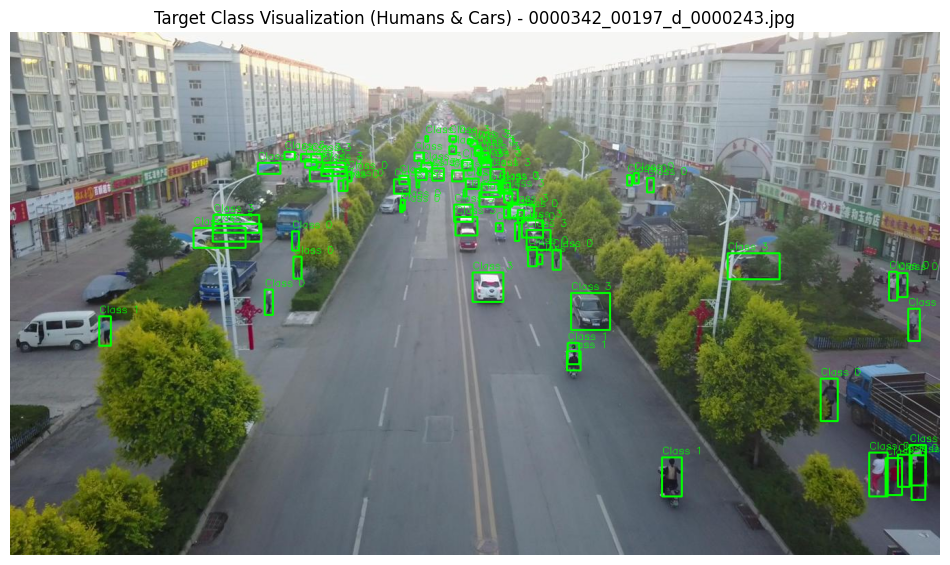

In [ ]:
TARGET_CLASSES = [0, 1, 3] # 0: pedestrian, 1: people, 3: car

# Select the same image as before
img_name = os.listdir(train_img_path)[0]
img_path = os.path.join(train_img_path, img_name)
label_path = os.path.join(train_lbl_path, img_name.replace('.jpg', '.txt'))

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

with open(label_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        data = line.split()
        if len(data) < 5: continue

        cls = int(data[0])

        # --- THE FILTER ---
        # Only proceed if the class is in our target list [0, 1, 3]
        if cls not in TARGET_CLASSES:
            continue

        x = float(data[1])
        y = float(data[2])
        w = float(data[3])
        h = float(data[4])

        # Convert normalized to pixels (as we did before)
        img_h, img_w, _ = image.shape
        x_min = int((x - w/2) * img_w)
        y_min = int((y - h/2) * img_h)
        x_max = int((x + w/2) * img_w)
        y_max = int((y + h/2) * img_h)

        # Draw the box
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

        # Use class ID as label
        cv2.putText(image, f"Class {cls}", (x_min, y_min - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(12,12))
plt.imshow(image)
plt.title(f"Target Class Visualization (Humans & Cars) - {img_name}")
plt.axis('off')
plt.show()

###1.3 Preprocessing & Augmentation

To prepare the VisDrone dataset for the YOLOv8 model, the following steps were implemented:

**Resizing**: All images are resized to
640
×
640
640×640
 pixels. This is the optimal input size for the YOLOv8 Nano model, balancing detection accuracy with real-time inference speed.

**Normalization**: Pixel values are normalized to a range of
[
0
,
1
]
[0,1]
 to ensure stable gradient descent during training.

**Augmentations:** To prevent overfitting and handle aerial perspective shifts, I utilize the following augmentations:

**Mosaic Augmentation:** Combines four images into one, helping the model detect smaller objects.

**Horizontal Flipping:** Increases dataset diversity by simulating different drone flight directions.

**Rotation & Scaling:** Handles various drone altitudes and orientations.

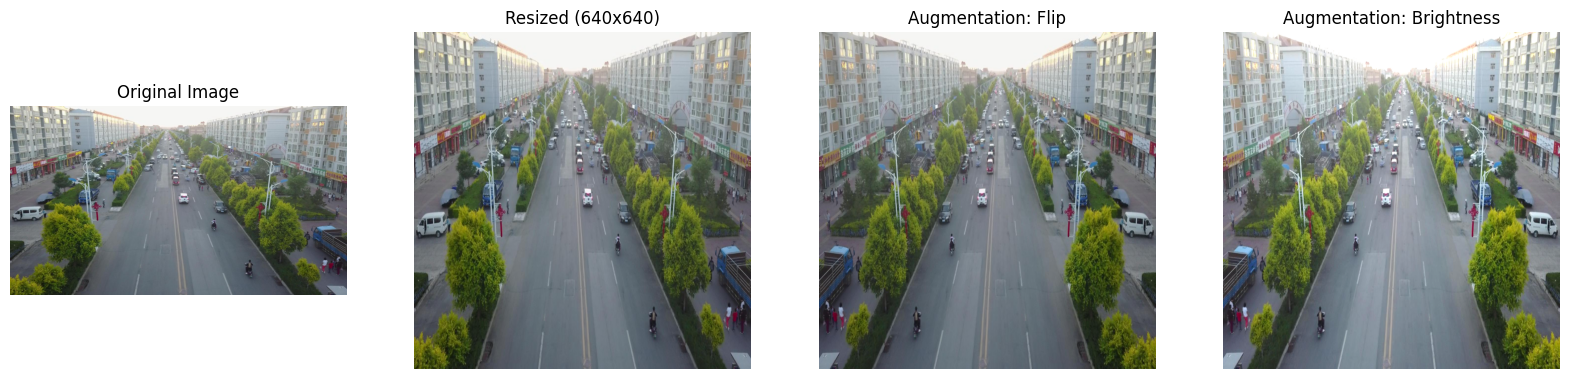

In [ ]:
# --- PREPROCESSING & AUGMENTATION DEMONSTRATION ---

def demonstrate_preprocessing(img_path):
    # 1. Load original image
    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # 2. RESIZING: Resize to 640x640 (What YOLO does)
    resized = cv2.resize(original, (640, 640))

    # 3. AUGMENTATION: Horizontal Flip (What YOLO does to increase diversity)
    flipped = cv2.flip(resized, 1) # 1 means horizontal flip

    # 4. AUGMENTATION: Brightness adjustment (Simulating different weather)
    # We multiply pixels by 1.2 to make it brighter
    brightened = cv2.convertScaleAbs(flipped, alpha=1.2, beta=0)

    return original, resized, flipped, brightened

# Pick one image from your train path
sample_img_name = os.listdir(train_img_path)[0]
sample_img_path = os.path.join(train_img_path, sample_img_name)

orig, res, flip, bright = demonstrate_preprocessing(sample_img_path)

# Visualize the results in a grid
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(orig)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(res)
axes[1].set_title("Resized (640x640)")
axes[1].axis('off')

axes[2].imshow(flip)
axes[2].set_title("Augmentation: Flip")
axes[2].axis('off')

axes[3].imshow(bright)
axes[3].set_title("Augmentation: Brightness")
axes[3].axis('off')

plt.show()

###1.4 Challenges Noticed in the Dataset
During the analysis of the VisDrone dataset, I identified three primary challenges:

**The Small Object Problem:** Pedestrians and cars at high altitudes occupy very few pixels. This often leads to "False Negatives" (missed detections).

**High Aspect Ratio:** Original drone images are often very wide. Resizing them to a square
640
×
640
640×640
 format can cause slight distortion.

**Class Imbalance:** There are significantly more car detections than pedestrian detections in urban scenes, which can bias the model.